In [1]:
!pip install segmentation-models-pytorch torch torchmetrics albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 6.9 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=05bc11e7e366ce8f75029bc8e668409c533c9bb98e38181a13c24b3eac69b749
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=530ba5b57b791e3622f00d6731a10175df681ce437921869edcca5d8a352ffe2
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Dice
import torchvision.models as models
import torch.nn.functional as F
from torch.nn import init

import segmentation_models_pytorch as smp

In [3]:
# Dataset paths
C_image_path = "/kaggle/input/pulmonary-chest-xray-abnormalities/ChinaSet_AllFiles/ChinaSet_AllFiles/CXR_png/"
C_masks_path = "/kaggle/input/shcxr-lung-mask/mask/"

# Output directories
BASE_OUTPUT_DIR = "/kaggle/working/segmentation"
TRAIN_IMAGE_DIR = os.path.join(BASE_OUTPUT_DIR, "train_images")
TRAIN_MASK_DIR  = os.path.join(BASE_OUTPUT_DIR, "train_masks")
TEST_IMAGE_DIR  = os.path.join(BASE_OUTPUT_DIR, "test_images")
TEST_MASK_DIR   = os.path.join(BASE_OUTPUT_DIR, "test_masks")

for d in [TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, TEST_IMAGE_DIR, TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

In [4]:
# List and sort image files
image_files = sorted([f for f in os.listdir(C_image_path) if f.endswith('.png')])
print("Number of Shenzhen images:", len(image_files))
# Full paths for image files
image_files_full = [os.path.join(C_image_path, f) for f in image_files]

Number of Shenzhen images: 662


In [5]:
# Shuffle and split 80% train, 20% test.
random.shuffle(image_files_full)
split_index = int(len(image_files_full) * 0.8)
train_files = image_files_full[:split_index]
test_files  = image_files_full[split_index:]

print("Number of training images:", len(train_files))
print("Number of test images:", len(test_files))

Number of training images: 529
Number of test images: 133


In [6]:
# Process each image (read, resize, binarize)

IMG_SIZE = (512, 512)
skipped = 0

for img_file in image_files_full:
    base_file = os.path.basename(img_file)
    # Determine corresponding mask filename.
    if "_mask" not in base_file:
        filename, ext = os.path.splitext(base_file)
        mask_filename = f"{filename}_mask{ext}"
    else:
        mask_filename = base_file
    mask_file = os.path.join(C_masks_path, mask_filename)
    
    image = cv2.imread(img_file)
    mask  = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    
    if image is None or mask is None:
        skipped += 1
        continue
    
    image_resized = cv2.resize(image, IMG_SIZE)
    mask_resized  = cv2.resize(mask, IMG_SIZE)
    
    # Binarize mask
    _, mask_binary = cv2.threshold(mask_resized, 128, 255, cv2.THRESH_BINARY)
    
    if img_file in train_files:
        cv2.imwrite(os.path.join(TRAIN_IMAGE_DIR, base_file), image_resized)
        cv2.imwrite(os.path.join(TRAIN_MASK_DIR, mask_filename), mask_binary)
    else:
        cv2.imwrite(os.path.join(TEST_IMAGE_DIR, base_file), image_resized)
        cv2.imwrite(os.path.join(TEST_MASK_DIR, mask_filename), mask_binary)
print(f"{skipped} images skipped.")

96 images skipped.


In [7]:
# Check count for each file (diagnostic).
train_image_count = len(os.listdir(TRAIN_IMAGE_DIR))
train_mask_count  = len(os.listdir(TRAIN_MASK_DIR))
test_image_count  = len(os.listdir(TEST_IMAGE_DIR))
test_mask_count   = len(os.listdir(TEST_MASK_DIR))

print("Training Images:", train_image_count)
print("Training Masks :", train_mask_count)
print("Testing Images :", test_image_count)
print("Testing Masks  :", test_mask_count)

Training Images: 452
Training Masks : 452
Testing Images : 114
Testing Masks  : 114


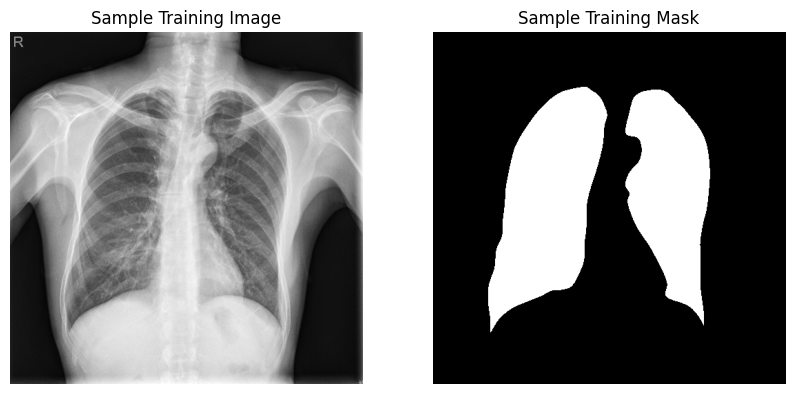

Unique pixel values in one training mask (CHNCXR_0060_0_mask.png): [  0 255]


In [8]:
# Display one random sample from training.
if train_image_count > 0:
    sample_train_image_name = random.choice(os.listdir(TRAIN_IMAGE_DIR))
    sample_train_image_path = os.path.join(TRAIN_IMAGE_DIR, sample_train_image_name)
    filename, ext = os.path.splitext(sample_train_image_name)
    if "_mask" not in sample_train_image_name:
        sample_train_mask_name = f"{filename}_mask{ext}"
    else:
        sample_train_mask_name = sample_train_image_name
    sample_train_mask_path = os.path.join(TRAIN_MASK_DIR, sample_train_mask_name)
    
    sample_train_image = cv2.imread(sample_train_image_path)
    sample_train_mask  = cv2.imread(sample_train_mask_path, cv2.IMREAD_GRAYSCALE)
    
    if sample_train_image is not None and sample_train_mask is not None:
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(sample_train_image, cv2.COLOR_BGR2RGB))
        plt.title("Sample Training Image")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(sample_train_mask, cmap="gray")
        plt.title("Sample Training Mask")
        plt.axis("off")
        plt.show()
    else:
        print("Could not load training sample image/mask.")
else:
    print("No training images found.")

# Check unique pixel values in one training mask.
if train_mask_count > 0:
    some_mask_file = os.path.join(TRAIN_MASK_DIR, os.listdir(TRAIN_MASK_DIR)[0])
    some_mask = cv2.imread(some_mask_file, cv2.IMREAD_GRAYSCALE)
    if some_mask is not None:
        unique_vals = np.unique(some_mask)
        print(f"Unique pixel values in one training mask ({os.path.basename(some_mask_file)}):", unique_vals)
    else:
        print("Could not load a training mask for pixel value check.")


In [9]:
img_transform = Compose([
    Resize(IMG_SIZE),
    ToTensor(),  # Converts the PIL image from [0,255] to [0,1] as a tensor.
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = Compose([
    Resize(IMG_SIZE),
    ToTensor()
])

In [10]:
def load_dataset(image_dir, mask_dir):
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    images = []
    masks = []
    for f in image_files:
        image_path = os.path.join(image_dir, f)
        # Construct the corresponding mask filename:
        if "_mask" not in f:
            filename, ext = os.path.splitext(f)
            mask_filename = f"{filename}_mask{ext}"
        else:
            mask_filename = f
        mask_path = os.path.join(mask_dir, mask_filename)
        # Load image and mask.
        image = Image.open(image_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")
        image = img_transform(image)
        mask = mask_transform(mask)
        mask = (mask > 0.5).float()  # Binarize mask.
        images.append(image)
        masks.append(mask)
    images_tensor = torch.stack(images)
    masks_tensor = torch.stack(masks)
    return TensorDataset(images_tensor, masks_tensor)

In [11]:
train_dataset = load_dataset(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
val_dataset   = load_dataset(TEST_IMAGE_DIR, TEST_MASK_DIR)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================================
# Attention Gate (AG) Implementation
# =======================================
# **ADDITION:** Attention_block module.
class Attention_block(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        """
        F_g : number of channels in the gating signal (from decoder).
        F_l : number of channels in the skip connection (from encoder).
        F_int: intermediate number of channels (typically set to F_l//2).
        """
        super(Attention_block, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        g1 = self.W_g(g)  # Process gating signal.
        x1 = self.W_x(x)  # Process encoder skip.
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)  # Generate attention map.
        return x * psi  # Return gated skip connection.

# =======================================
# Custom U-Net with ResNet34 Encoder & AG on Skip Connections
# =======================================
# **MODIFICATION:** Replacing CBAM with Attention Gates.
import torchvision.models as models
import torch.nn.functional as F

class UNetResNet34_AG(nn.Module):
    def __init__(self, n_classes):
        super(UNetResNet34_AG, self).__init__()
        # Encoder: Pretrained ResNet34.
        resnet = models.resnet34(pretrained=True)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)    # Output: 64 channels [B,64,H/2,W/2]
        self.layer1 = nn.Sequential(resnet.maxpool, resnet.layer1)             # Output: 64 channels [B,64,H/4,W/4]
        self.layer2 = resnet.layer2                                             # Output: 128 channels [B,128,H/8,W/8]
        self.layer3 = resnet.layer3                                             # Output: 256 channels [B,256,H/16,W/16]
        self.layer4 = resnet.layer4                                             # Output: 512 channels [B,512,H/32,W/32]
        
        # Attention Gates for skip connections.
        # For skip connection from layer3: use gating signal from d4 (256 channels).
        self.attn3 = Attention_block(F_g=256, F_l=256, F_int=128)
        # For skip connection from layer2: use gating signal from d3 (128 channels).
        self.attn2 = Attention_block(F_g=128, F_l=128, F_int=64)
        # For skip connection from layer1: use gating signal from d2 (64 channels).
        self.attn1 = Attention_block(F_g=64, F_l=64, F_int=32)
        # For skip connection from layer0: use gating signal from d1 (64 channels).
        self.attn0 = Attention_block(F_g=64, F_l=64, F_int=32)
        
        # Decoder Blocks.
        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # Upsample bottleneck.
        self.decoder3 = nn.Sequential(
            nn.Conv2d(256 + 256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = nn.Sequential(
            nn.Conv2d(128 + 128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.decoder0 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder forward pass.
        x0 = self.layer0(x)   # [B,64,H/2,W/2]
        x1 = self.layer1(x0)  # [B,64,H/4,W/4]
        x2 = self.layer2(x1)  # [B,128,H/8,W/8]
        x3 = self.layer3(x2)  # [B,256,H/16,W/16]
        x4 = self.layer4(x3)  # [B,512,H/32,W/32]
        
        # Decoder with Attention Gates on skip connections.
        d4 = self.upconv4(x4)  # [B,256,H/16,W/16]
        # Apply attention gate using gating signal d4 and skip x3.
        x3_att = self.attn3(g=d4, x=x3)
        d4 = torch.cat([d4, x3_att], dim=1)  # [B,256+256,H/16,W/16]
        d4 = self.decoder3(d4)              # [B,256,H/16,W/16]
        
        d3 = self.upconv3(d4)  # [B,128,H/8,W/8]
        x2_att = self.attn2(g=d3, x=x2)
        d3 = torch.cat([d3, x2_att], dim=1)  # [B,128+128,H/8,W/8]
        d3 = self.decoder2(d3)              # [B,128,H/8,W/8]
        
        d2 = self.upconv2(d3)  # [B,64,H/4,W/4]
        x1_att = self.attn1(g=d2, x=x1)
        d2 = torch.cat([d2, x1_att], dim=1)  # [B,64+64,H/4,W/4]
        d2 = self.decoder1(d2)              # [B,64,H/4,W/4]
        
        d1 = self.upconv1(d2)  # [B,64,H/2,W/2]
        x0_att = self.attn0(g=d1, x=x0)
        d1 = torch.cat([d1, x0_att], dim=1)  # [B,64+64,H/2,W/2]
        d1 = self.decoder0(d1)              # [B,64,H/2,W/2]
        
        out = self.final_conv(d1)           # [B,n_classes,H/2,W/2]
        # **MODIFICATION:** Upsample to match input resolution (512x512)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)
        return out

model = UNetResNet34_AG(n_classes=1)
model = model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 192MB/s]


In [13]:
# Loss function
loss_fn = smp.losses.DiceLoss(mode='binary')

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Metrics
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
accuracy_metric = BinaryAccuracy(threshold=0.5).to(device)
dice_metric = Dice(threshold=0.5).to(device)

In [14]:
# Training hyperparameters.
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 25

score_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_accuracy': [],
    'val_dice': []
}

# Training loop.
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)  # Already in [0,1] and shape [B,1,H,W]
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    # Reset metrics before validation.
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item() * images.size(0)
            
            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()
            
            # Convert predictions and masks to int
            preds_int = preds.long()
            masks_int = masks.long()
            
            # Update metrics for current batch.
            iou_metric.update(preds_int, masks_int)
            accuracy_metric.update(preds_int, masks_int)
            dice_metric.update(preds_int, masks_int)
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_iou = iou_metric.compute().item()
    avg_acc = accuracy_metric.compute().item()
    avg_dice = dice_metric.compute().item()
    
    # Reset metrics after epoch.
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()

    score_history['epoch'].append(epoch + 1)
    score_history['train_loss'].append(avg_train_loss)
    score_history['val_loss'].append(avg_val_loss)
    score_history['val_iou'].append(avg_iou)
    score_history['val_accuracy'].append(avg_acc)
    score_history['val_dice'].append(avg_dice)

    # Early stopping check.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_iou:.4f}, Val Accuracy: {avg_acc:.4f}, Val Dice: {avg_dice:.4f}")

Epoch [1/25]
Train Loss: 0.4099
Val Loss: 0.0604, Val IoU: 0.8873, Val Accuracy: 0.9704, Val Dice: 0.9704
Epoch [2/25]
Train Loss: 0.0515
Val Loss: 0.0473, Val IoU: 0.9108, Val Accuracy: 0.9764, Val Dice: 0.9764
Epoch [3/25]
Train Loss: 0.0431
Val Loss: 0.0462, Val IoU: 0.9131, Val Accuracy: 0.9775, Val Dice: 0.9775
Epoch [4/25]
Train Loss: 0.0404
Val Loss: 0.0428, Val IoU: 0.9192, Val Accuracy: 0.9788, Val Dice: 0.9788
Epoch [5/25]
Train Loss: 0.0370
Val Loss: 0.0444, Val IoU: 0.9162, Val Accuracy: 0.9779, Val Dice: 0.9779
Epoch [6/25]
Train Loss: 0.0364
Val Loss: 0.0448, Val IoU: 0.9157, Val Accuracy: 0.9782, Val Dice: 0.9782
Epoch [7/25]
Train Loss: 0.0334
Val Loss: 0.0422, Val IoU: 0.9204, Val Accuracy: 0.9794, Val Dice: 0.9794
Epoch [8/25]
Train Loss: 0.0330
Val Loss: 0.0459, Val IoU: 0.9137, Val Accuracy: 0.9779, Val Dice: 0.9779
Epoch [9/25]
Train Loss: 0.0321
Val Loss: 0.0421, Val IoU: 0.9203, Val Accuracy: 0.9791, Val Dice: 0.9791
Epoch [10/25]
Train Loss: 0.0281
Val Loss: 0.0

In [15]:
torch.save(model.state_dict(), "/kaggle/working/Lung_Unet_34_AG.pth")

In [16]:
df_scores = pd.DataFrame(score_history)
df_scores.to_csv("/kaggle/working/Lung_Unet_34_AG_Scores.csv", index=False)
print("Training scores saved.")

Training scores saved.
